In [ ]:
#'block_size': 256,
#'n_embed': 384,
#'n_layers': 6,
#'n_heads': 6,

# TODO: current 4.59 it/s
# TODO: word tokenizer
# TODO: visualize attention
# TODO: visualize gradient issues
# TODO: how does lpad work, does it?
# TODO: without residuals
# TODO: without layer norm
# TODO: without bias?
# TODO: make sampling faster
# TODO: how to measure model quality?

CONFIG = {
    "seq_len": 128, # TODO: call block_size
    "batch_size": 128,
    "embed_size": 64, #
    "num_heads": 2, # TODO: why can't I use 6 heads?
    "num_layers": 20,
    "learning_rate": 3e-4,
    "max_steps": 500,
    #"dropout": 0.1,
    "layer_norm_enabled": True,
}

"""
CONFIG = {
    "seq_len": 128,  # Increased from 10 - critical for learning context
    "batch_size": 64,  # Increased from 4 - better gradient estimates
    "embed_size": 128,  # Increased from 32 - more model capacity
    "num_heads": 4,  # Increased from 2 - better attention patterns (embed_size must be divisible)
    "num_layers": 4,  # Increased from 2 - deeper model for better learning
    "dropout": 0.1,  # Enable dropout for regularization
    "learning_rate": 3e-4,  # Standard for transformers (AdamW)
    "weight_decay": 0.1,  # L2 regularization
    "max_steps": 1000,  # More training steps
}
"""


'\nCONFIG = {\n    "seq_len": 128,  # Increased from 10 - critical for learning context\n    "batch_size": 64,  # Increased from 4 - better gradient estimates\n    "embed_size": 128,  # Increased from 32 - more model capacity\n    "num_heads": 4,  # Increased from 2 - better attention patterns (embed_size must be divisible)\n    "num_layers": 4,  # Increased from 2 - deeper model for better learning\n    "dropout": 0.1,  # Enable dropout for regularization\n    "learning_rate": 3e-4,  # Standard for transformers (AdamW)\n    "weight_decay": 0.1,  # L2 regularization\n    "max_steps": 1000,  # More training steps\n}\n'

In [2]:
import torch
DEVICE = torch.device("mps")

Load dataset:

In [3]:
import requests
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATASET_TEXT = requests.get(url).text
#DATASET_TEXT = DATASET_TEXT[:1000]

Find tokens:

In [4]:
chars = sorted(list(set(DATASET_TEXT)))
chars

['\n',
 ' ',
 '!',
 '$',
 '&',
 "'",
 ',',
 '-',
 '.',
 '3',
 ':',
 ';',
 '?',
 'A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'J',
 'K',
 'L',
 'M',
 'N',
 'O',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'U',
 'V',
 'W',
 'X',
 'Y',
 'Z',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

Create tokenizer:

In [5]:
ctoi = {c:i for i, c in enumerate(chars)}
itoc = {i:c for i, c in enumerate(chars)}
encode = lambda text: [ctoi[c] for c in text]
decode = lambda tokens: "".join([itoc[i] for i in tokens])
decode(encode("hello world"))

'hello world'

Create token embedding table:

In [6]:
import torch
import torch.nn as nn

vocab_size = len(ctoi)
embed_size = CONFIG["embed_size"]
CONFIG["vocab_size"] = vocab_size

seq_len = CONFIG["seq_len"]
pad = lambda text: " " * max(0, seq_len - len(text)) + text
text = pad("hello")
tokens = torch.tensor(encode(text))
token_embedding_table = nn.Embedding(vocab_size, embed_size)
tokens_emb = token_embedding_table(tokens)
tokens_emb.shape, tokens_emb

(torch.Size([128, 64]),
 tensor([[ 0.9239, -1.6999, -0.6992,  ..., -0.2852,  1.4451,  0.9291],
         [ 0.9239, -1.6999, -0.6992,  ..., -0.2852,  1.4451,  0.9291],
         [ 0.9239, -1.6999, -0.6992,  ..., -0.2852,  1.4451,  0.9291],
         ...,
         [ 0.8816,  0.8237,  0.8423,  ...,  0.2135,  1.1270,  0.5629],
         [ 0.8816,  0.8237,  0.8423,  ...,  0.2135,  1.1270,  0.5629],
         [ 0.7227,  0.0351, -0.0175,  ...,  0.9229, -0.7768, -0.7768]],
        grad_fn=<EmbeddingBackward0>))

Create position embedding table:

In [7]:
seq_len = CONFIG["seq_len"]
embed_size = CONFIG["embed_size"]

position_embedding_table = nn.Embedding(seq_len, embed_size)
positions = torch.arange(seq_len)
positions_emb = position_embedding_table(positions)
positions_emb.shape, positions_emb

(torch.Size([128, 64]),
 tensor([[-3.0696e+00, -5.9414e-01, -6.6320e-02,  ...,  2.9236e-02,
          -3.9124e-01,  1.4590e+00],
         [ 3.9607e-01,  1.0877e-01, -1.5191e-03,  ..., -2.9819e-01,
          -2.7955e+00,  9.0303e-01],
         [-9.0251e-01,  6.2202e-01, -2.1528e-01,  ..., -7.2600e-01,
          -1.1429e-03,  1.5903e-01],
         ...,
         [-1.0604e+00,  8.6968e-02, -3.6369e-01,  ...,  9.4692e-01,
          -2.4760e-01, -7.9539e-02],
         [ 6.0375e-01,  5.1462e-01, -5.2251e-01,  ..., -5.3170e-01,
          -1.0575e+00, -3.5150e-01],
         [-1.2720e+00, -1.0678e-01, -9.1571e-01,  ..., -9.4826e-01,
           3.5629e-01,  7.1486e-01]], grad_fn=<EmbeddingBackward0>))

Test combining token embeddings and positions embeddings:

In [8]:
x = tokens_emb + positions_emb
x.shape, x

(torch.Size([128, 64]),
 tensor([[-2.1457, -2.2940, -0.7655,  ..., -0.2559,  1.0539,  2.3881],
         [ 1.3199, -1.5911, -0.7007,  ..., -0.5833, -1.3504,  1.8321],
         [ 0.0214, -1.0779, -0.9145,  ..., -1.0112,  1.4440,  1.0881],
         ...,
         [-0.1788,  0.9107,  0.4786,  ...,  1.1604,  0.8794,  0.4834],
         [ 1.4854,  1.3384,  0.3198,  ..., -0.3182,  0.0695,  0.2114],
         [-0.5493, -0.0716, -0.9332,  ..., -0.0254, -0.4205, -0.0619]],
        grad_fn=<AddBackward0>))

Create batch sampler:

In [9]:
DATASET_TOKENS = encode(DATASET_TEXT)

def sample_batch(batch_len):
    seq_len = CONFIG["seq_len"]
    xs, ys = [], []
    for _ in range(batch_len):
        offset_idx = torch.randint(len(DATASET_TOKENS) - seq_len, (1,))
        x = DATASET_TOKENS[offset_idx:offset_idx+seq_len]
        y = DATASET_TOKENS[offset_idx+1:offset_idx+seq_len+1]
        xs.append(x)
        ys.append(y)
    return torch.tensor(xs), torch.tensor(ys)

x, y = sample_batch(10)
x.shape, x, y.shape, y


(torch.Size([10, 128]),
 tensor([[53, 52,  0,  ..., 39, 63,  1],
         [63, 43, 57,  ..., 39, 56, 42],
         [14, 17, 24,  ..., 63,  1, 50],
         ...,
         [ 2,  1, 63,  ...,  1, 51, 63],
         [27, 10,  0,  ...,  6,  0, 31],
         [61, 39, 63,  ..., 47, 56, 43]]),
 torch.Size([10, 128]),
 tensor([[52,  0, 18,  ..., 63,  1, 58],
         [43, 57,  1,  ..., 56, 42,  5],
         [17, 24, 24,  ...,  1, 50, 53],
         ...,
         [ 1, 63, 53,  ..., 51, 63,  1],
         [10,  0, 37,  ...,  0, 31, 46],
         [39, 63,  6,  ..., 56, 43,  1]]))

Test decoding batch:

In [10]:
for i in range(x.shape[0]):
    x_tokens = x[i].tolist()
    y_tokens = y[i].tolist()
    print(f"x {i}: {decode(x_tokens)}")
    print(f"y {i}: {decode(y_tokens)}")
    print()

x 0: on
Fridays. He's not past it yet, and I say to thee,
he would mouth with a beggar, though she smelt brown
bread and garlic: say 
y 0: n
Fridays. He's not past it yet, and I say to thee,
he would mouth with a beggar, though she smelt brown
bread and garlic: say t

x 1: yes the witness of this ill:
See how I am bewitch'd; behold mine arm
Is, like a blasted sapling, wither'd up:
And this is Edward
y 1: es the witness of this ill:
See how I am bewitch'd; behold mine arm
Is, like a blasted sapling, wither'd up:
And this is Edward'

x 2: BELLA:
Gentle my lord, turn back.

ANGELO:
I will bethink me: come again tomorrow.

ISABELLA:
Hark how I'll bribe you: good my l
y 2: ELLA:
Gentle my lord, turn back.

ANGELO:
I will bethink me: come again tomorrow.

ISABELLA:
Hark how I'll bribe you: good my lo

x 3: yet he had lived!
A lack, when once our grace we have forgot,
Nothing goes right: we would, and we would not.

DUKE VINCENTIO:
T
y 3: et he had lived!
A lack, when once our grace we have f

In [11]:
batch_size = CONFIG["batch_size"]
seq_len = CONFIG["seq_len"]
x, _ = sample_batch(batch_size)
x_emb = token_embedding_table(x)
positions = torch.arange(seq_len)
pos_emb = position_embedding_table(positions)
x = x_emb + pos_emb
x.shape, x[0][0]

(torch.Size([128, 128, 64]),
 tensor([-2.7636,  0.8845,  1.2755,  0.5164, -0.7385,  1.3347,  0.7729,  1.0598,
          0.3671,  0.3266,  1.8056, -1.4212, -0.3065, -0.3058, -0.3567, -1.4413,
         -0.3863,  0.6825, -0.6074,  0.2572,  0.5062, -1.1866, -0.3489, -0.1572,
         -1.1709,  2.1993, -1.7657, -0.2045, -0.1037,  0.3014, -0.4866,  0.9218,
          1.3056, -4.1396, -0.2405,  1.0077,  0.4165, -1.6442,  0.6109,  0.4996,
          0.1427,  0.8631, -0.5003, -1.1830,  0.6781,  0.3822, -1.2012,  0.8843,
          1.9518, -2.3294, -0.0159, -1.6369, -0.1101,  0.4914, -0.3127, -1.1885,
         -2.1679, -2.8828,  1.9163,  3.1948,  1.6000, -0.2366,  0.5524,  1.5308],
        grad_fn=<SelectBackward0>))

In [12]:
qkv_shape = (CONFIG["embed_size"], CONFIG["embed_size"]) # TODO; call embed_dim
Wq = torch.randn(qkv_shape)
Wk = torch.randn(qkv_shape)
Wv = torch.randn(qkv_shape)

In [13]:
Q = x @ Wq
K = x @ Wk
V = x @ Wv
Q.shape, K.shape, V.shape

(torch.Size([128, 128, 64]),
 torch.Size([128, 128, 64]),
 torch.Size([128, 128, 64]))

In [14]:
Kt = K.transpose(-2, -1)
Kt.shape

torch.Size([128, 64, 128])

In [15]:
QKt = Q @ Kt # (B, T, C) @ (B, C, T) -> (B, T, T)
QKt.shape, QKt[0][0]

(torch.Size([128, 128, 128]),
 tensor([ -256.9787,  -434.9782,  2092.5171,  -750.1899,  -198.6971,   146.2636,
          -586.9825, -2304.5374,   -88.1056,  -938.6110,  -548.4102,   976.7526,
          -284.7561,  -366.6838,   170.4997,   391.3927,  -269.1228,  -309.2702,
           459.4611,   352.2251,  2228.5930,   527.4666,   244.4595,   452.3752,
           337.8697,   929.3149, -1071.7517,   763.7787,  -323.2068,   402.6324,
          1575.5076,   113.3293,    81.3766,    12.6608,  -647.1711,  1602.1956,
         -1198.0786, -1351.9662, -1723.0464,  -451.4516,  -633.0520,  -698.1077,
           922.1846,  1495.3960,  2039.8708,  -975.2277,  -186.1686,  1340.2653,
           318.3380,  -637.7286,  -697.0207,  -734.7230,  -678.3947,  -317.1028,
          -441.9632,   614.4983, -1505.7527,  -355.8239, -1589.8129,     4.7115,
            22.7587,   706.8572,  -554.3969,  -461.5358,  -240.7804,   880.5834,
          -116.0063,   439.8824,   633.4686, -1141.6974, -2049.1987,   654.3378

In [16]:
QKt_scaled = QKt / torch.sqrt(torch.tensor(embed_size))
QKt_scaled.shape, QKt_scaled[0][0]

(torch.Size([128, 128, 128]),
 tensor([ -32.1223,  -54.3723,  261.5646,  -93.7737,  -24.8371,   18.2829,
          -73.3728, -288.0672,  -11.0132, -117.3264,  -68.5513,  122.0941,
          -35.5945,  -45.8355,   21.3125,   48.9241,  -33.6403,  -38.6588,
           57.4326,   44.0281,  278.5741,   65.9333,   30.5574,   56.5469,
           42.2337,  116.1644, -133.9690,   95.4723,  -40.4009,   50.3290,
          196.9384,   14.1662,   10.1721,    1.5826,  -80.8964,  200.2744,
         -149.7598, -168.9958, -215.3808,  -56.4315,  -79.1315,  -87.2635,
          115.2731,  186.9245,  254.9839, -121.9035,  -23.2711,  167.5332,
           39.7922,  -79.7161,  -87.1276,  -91.8404,  -84.7993,  -39.6379,
          -55.2454,   76.8123, -188.2191,  -44.4780, -198.7266,    0.5889,
            2.8448,   88.3571,  -69.2996,  -57.6920,  -30.0976,  110.0729,
          -14.5008,   54.9853,   79.1836, -142.7122, -256.1498,   81.7922,
          -23.4163, -108.8253,  229.4243, -399.7444,   74.5737,  -81.9

In [17]:
tril = torch.tril(torch.ones((seq_len, seq_len)))
tril

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [1., 1., 0.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.],
        ...,
        [1., 1., 1.,  ..., 1., 0., 0.],
        [1., 1., 1.,  ..., 1., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]])

In [18]:
mask = tril == 0
mask

tensor([[False,  True,  True,  ...,  True,  True,  True],
        [False, False,  True,  ...,  True,  True,  True],
        [False, False, False,  ...,  True,  True,  True],
        ...,
        [False, False, False,  ..., False,  True,  True],
        [False, False, False,  ..., False, False,  True],
        [False, False, False,  ..., False, False, False]])

In [19]:
QKt_scaled_masked = QKt_scaled.masked_fill(mask, float("-inf"))
QKt_scaled_masked.shape, QKt_scaled_masked[0]

(torch.Size([128, 128, 128]),
 tensor([[ -32.1223,      -inf,      -inf,  ...,      -inf,      -inf,
               -inf],
         [ 200.8308, -160.9523,      -inf,  ...,      -inf,      -inf,
               -inf],
         [  27.7102,  -18.6489,   89.9607,  ...,      -inf,      -inf,
               -inf],
         ...,
         [-121.9916,   53.6856,  -30.4907,  ...,   85.0005,      -inf,
               -inf],
         [ 127.9781, -291.7145,   -4.9901,  ...,  239.1315,   31.0275,
               -inf],
         [ -10.4101,   -2.9698, -124.8850,  ...,    6.9765,  203.2956,
            73.0942]], grad_fn=<SelectBackward0>))

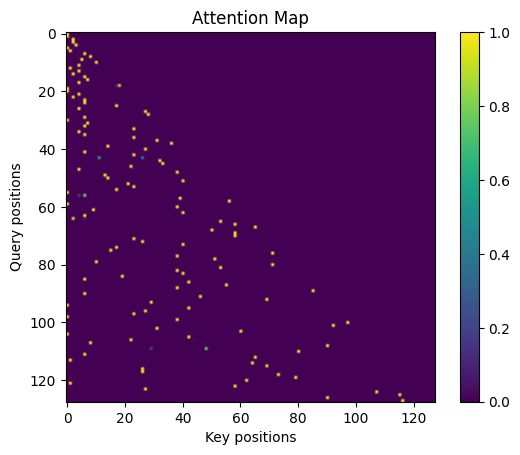

In [20]:
from torch.nn import functional as F
import matplotlib.pyplot as plt

attention = F.softmax(QKt_scaled_masked, dim=-1)

plt.imshow(attention[0].detach().cpu(), cmap='viridis')
plt.colorbar()
plt.title("Attention Map")
plt.xlabel("Key positions")
plt.ylabel("Query positions")
plt.show()

In [21]:
output = attention @ V
output.shape

torch.Size([128, 128, 64])

In [22]:
ffn1 = nn.Linear(embed_size, embed_size * 4)
gelu = nn.GELU()
ffn2 = nn.Linear(embed_size * 4, embed_size)
n_heads = CONFIG["num_heads"]
head_size = embed_size // n_heads
lm_head = nn.Linear(embed_size, head_size)
output_head = lm_head(ffn2(gelu(ffn1(output))))
output_head.shape, output_head

(torch.Size([128, 128, 32]),
 tensor([[[ 5.3079e-01, -1.5991e+00, -7.1978e-01,  ..., -6.4720e-01,
           -1.2636e+00, -1.1100e+00],
          [ 5.3079e-01, -1.5991e+00, -7.1978e-01,  ..., -6.4720e-01,
           -1.2636e+00, -1.1100e+00],
          [ 3.6864e-01, -1.9766e+00,  2.3052e-01,  ...,  6.8866e-01,
           -2.1667e+00,  1.6623e-01],
          ...,
          [ 6.9914e-01,  1.0053e+00, -2.6064e-01,  ..., -2.3068e+00,
           -2.3695e-01,  1.2974e+00],
          [-1.2547e+00,  4.7855e-02, -4.3214e-01,  ...,  2.5077e-01,
           -3.9434e+00,  1.3854e+00],
          [ 1.1578e+00, -3.1892e+00, -1.8555e+00,  ..., -2.8593e+00,
           -4.0732e+00,  7.6829e-01]],
 
         [[-7.2019e-01, -4.0451e-01, -1.4959e+00,  ...,  1.6324e+00,
           -1.5037e+00, -1.1605e-02],
          [-7.2019e-01, -4.0451e-01, -1.4959e+00,  ...,  1.6324e+00,
           -1.5037e+00, -1.1605e-02],
          [ 8.6808e-01,  7.7192e-01, -1.7317e-01,  ..., -2.1718e+00,
           -1.3676e+00, -1.8

In [23]:
class AttentionHead(nn.Module):
    def __init__(self, head_size):
        nn.Module.__init__(self)
        
        self.head_size = head_size
        embed_size = CONFIG["embed_size"]

        self.W_q = nn.Linear(embed_size, head_size)
        self.W_k = nn.Linear(embed_size, head_size)
        self.W_v = nn.Linear(embed_size, head_size)

        seq_len = CONFIG["seq_len"]
        self.register_buffer("tril", torch.tril(torch.ones(seq_len, seq_len)))
        
    def forward(self, x):
        B, T, C = x.shape
        #print("WORKED BTC", B, T, C)

        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)
        Kt = K.transpose(-2, -1)
        QKt = Q @ Kt
        QKt_scaled = QKt / torch.sqrt(torch.tensor(self.head_size))
        #mask = self.tril == 0

        mask = self.tril[:T, :T].to(x.device).bool()   # (T, T)
        #mask = mask.unsqueeze(0)   # (1, 1, T, T) if needed
        #print("MASK", mask.shape)
        #print("QKt_scaled", QKt_scaled.shape)

        QKt_masked = QKt_scaled.masked_fill(~mask, float("-inf"))
        attention = F.softmax(QKt_masked, dim=-1) # TODO: confirm this
        out = attention @ V

        return out

x, y = sample_batch(1)
x = token_embedding_table(x)
out = AttentionHead(3)(x)
out.shape, out

(torch.Size([1, 128, 3]),
 tensor([[[-0.2270,  0.0210, -0.1117],
          [-0.2388,  0.1227,  0.0015],
          [-0.3035,  0.0840,  0.1376],
          [-0.1552,  0.0909,  0.0898],
          [ 0.0468,  0.0350, -0.1199],
          [-0.1443,  0.0139,  0.0497],
          [-0.2066,  0.0251,  0.0611],
          [-0.1860,  0.0891,  0.1584],
          [-0.1499,  0.0516,  0.1415],
          [-0.1088, -0.0634,  0.1897],
          [-0.0935, -0.0784,  0.1604],
          [ 0.0163, -0.1043,  0.1279],
          [-0.0622, -0.0914,  0.1250],
          [ 0.0121, -0.0662,  0.2072],
          [ 0.0216, -0.0715,  0.1793],
          [ 0.1996, -0.0621,  0.1467],
          [ 0.1469, -0.0877,  0.1598],
          [ 0.1391, -0.0609,  0.1320],
          [ 0.1745, -0.0442,  0.0915],
          [ 0.1328,  0.0505,  0.0956],
          [ 0.1042, -0.0654,  0.1065],
          [ 0.1482, -0.0989,  0.0947],
          [ 0.0748, -0.0690,  0.0523],
          [ 0.1067, -0.0796,  0.0237],
          [ 0.1078, -0.0762,  0.0747],

In [24]:
class MultiHeadAttention(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        
        n_heads = CONFIG["num_heads"]
        embed_size = CONFIG["embed_size"]
        head_size = embed_size // n_heads
        self.heads = nn.ModuleList([AttentionHead(head_size) for _ in range(n_heads)])
        self.W_o = nn.Linear(embed_size, embed_size)

    def forward(self, x):
        outs = []
        for head in self.heads: # TODO: for here?
            out = head(x)
            outs.append(out)
        mha_out = torch.concat(outs, dim=-1)
        mha_out = self.W_o(mha_out)
        return mha_out

x, _ = sample_batch(1)
x = token_embedding_table(x)
out = MultiHeadAttention()(x)
out.shape, out

(torch.Size([1, 128, 64]),
 tensor([[[-0.1232,  0.0685, -0.1261,  ...,  0.0199, -0.1046,  0.4309],
          [-0.4135, -0.0723,  0.3499,  ..., -0.1210,  0.0499,  0.5429],
          [-0.1622,  0.1449,  0.1097,  ..., -0.2018,  0.0585,  0.3340],
          ...,
          [-0.1230,  0.0521,  0.0485,  ..., -0.1207, -0.1074,  0.1895],
          [-0.1074,  0.0690,  0.0610,  ..., -0.1314, -0.0889,  0.2028],
          [-0.1075,  0.0749,  0.0589,  ..., -0.1528, -0.0460,  0.1990]]],
        grad_fn=<ViewBackward0>))

In [25]:
class FeedForward(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        
        embed_size = CONFIG["embed_size"]
        self.ffn1 = nn.Linear(embed_size, embed_size * 4)
        self.gelu = nn.GELU()
        self.ffn2 = nn.Linear(embed_size * 4, embed_size)

    def forward(self, x):
        x = self.ffn1(x)
        x = self.gelu(x)
        x = self.ffn2(x)
        return x

x,y = sample_batch(1)
x = token_embedding_table(x)
mha_out = MultiHeadAttention()(x)
out = FeedForward()(mha_out)
out.shape, out

(torch.Size([1, 128, 64]),
 tensor([[[-0.0880,  0.1461,  0.0309,  ...,  0.0939, -0.0300,  0.0376],
          [-0.0040,  0.0967, -0.0229,  ...,  0.0592, -0.0204, -0.0195],
          [-0.0002,  0.0521, -0.0433,  ...,  0.0567, -0.0087, -0.0436],
          ...,
          [ 0.0034,  0.0345, -0.0470,  ...,  0.0342, -0.0049, -0.0647],
          [-0.0041,  0.0428, -0.0416,  ...,  0.0404, -0.0081, -0.0489],
          [-0.0037,  0.0343, -0.0427,  ...,  0.0345, -0.0143, -0.0511]]],
        grad_fn=<ViewBackward0>))

In [26]:
class Block(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        self.head = MultiHeadAttention()
        self.ffn = FeedForward()
        self.ln1 = nn.LayerNorm(embed_size)
        self.ln2 = nn.LayerNorm(embed_size)

    def forward(self, x):
        if CONFIG["layer_norm_enabled"]:
            x = x + self.head(self.ln1(x))  # Normalize input to attention
        else:
            x = x + self.head(x)
        
        if CONFIG["layer_norm_enabled"]:
            x = x + self.ffn(self.ln2(x))  # Normalize input to FFN
        else:
            x = x + self.ffn(x)
        return x

x, y = sample_batch(1)
x = token_embedding_table(x)
out = Block()(x)
out.shape, out

(torch.Size([1, 128, 64]),
 tensor([[[ 0.3597,  0.4844,  0.8252,  ...,  1.1972, -0.7158, -0.6883],
          [-0.7209, -0.0053,  1.9235,  ..., -0.0259, -0.3933,  0.8026],
          [ 1.6803, -0.3904,  0.2665,  ...,  0.0260,  0.1633,  0.4956],
          ...,
          [-0.1272, -0.8526, -1.4783,  ...,  1.4974, -0.9104, -0.4265],
          [-0.4225,  0.8867, -0.4393,  ...,  0.3295, -1.3049, -0.9488],
          [ 1.2875, -1.6703, -0.2215,  ..., -0.2748,  1.8240,  1.0776]]],
        grad_fn=<AddBackward0>))

In [27]:
tokens = encode(pad("hello"))
tokens_t = torch.tensor(tokens)
tokens_t = tokens_t.view(1, seq_len)
tokens_t

tensor([[ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, 46, 43, 50,
         50, 53]])

In [28]:
class Transformer(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)

        self.token_embedding_table = nn.Embedding(vocab_size, embed_size)
        self.position_embedding_table = nn.Embedding(CONFIG["seq_len"], embed_size)

        # TODO: seq vs parallel
        self.blocks = nn.ModuleList([Block() for _ in range(CONFIG["num_layers"])])
        self.lm_head = nn.Linear(CONFIG["embed_size"], CONFIG["vocab_size"])
        self.ln_final = nn.LayerNorm(embed_size)

    def forward(self, x):
        B, T = x.shape
        tok_emb = self.token_embedding_table(x)        # (B, T, C)
        pos = torch.arange(T, device=x.device)         # (T,)
        pos_emb = self.position_embedding_table(pos)   # (T, C)
        pos_emb = pos_emb.unsqueeze(0)                 # (1, T, C) -> broadcasts over batch
        x = tok_emb + pos_emb      
        for block in self.blocks: x = block(x)
        if CONFIG["layer_norm_enabled"]: x = self.ln_final(x)
        x = self.lm_head(x)
        return x

    @torch.no_grad()
    def generate(self, text, max_len=20):
        device = next(self.parameters()).device
        seq_len = CONFIG["seq_len"]
        tokens = encode(text)
        tokens_t = torch.tensor(tokens).to(device)
        tokens_t = tokens_t.unsqueeze(0)#view(1, -1)
        output_tokens = []
        while len(output_tokens) < max_len:
            logits = self(tokens_t)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx = torch.multinomial(probs, num_samples=1)
            idx = idx.squeeze().item()
            tokens.append(idx)
            tokens = tokens[-seq_len:]
            tokens_t = torch.tensor(tokens).to(device).unsqueeze(0)
            #tokens_t = tokens_t.view(1, seq_len)
            output_tokens.append(idx)
        text = decode(output_tokens)
        return text


x, y = sample_batch(1)
out = Transformer()(x)
out.shape, out[0][0]

#text = Transformer().generate("hello")
#print(text)

(torch.Size([1, 128, 65]),
 tensor([-1.8899, -5.0922,  1.3630,  2.9803, -1.5593, -3.4196, -4.9109,  6.9193,
          2.0088, -1.1581, -1.7668, -3.3464,  6.8841,  2.5787, -7.4263,  3.5668,
          2.3635, -5.3181,  5.4913, -5.6317,  2.9537, -8.1998, -2.2044,  3.4752,
         -6.1313, -1.3491, -4.0184,  3.3551, -7.0089,  3.9520,  0.6872, -2.3286,
          1.9637, -1.9285,  3.7608, -3.1618,  3.0332,  2.3301, -1.9078,  3.8301,
         -0.2838, -3.0113,  5.9470, -3.8139, -0.6193, -6.9800, -7.1601,  4.8396,
         -0.1381, -2.5621,  0.0860,  0.0774, -0.2845,  7.6378, -5.0271,  3.6926,
         -3.7131, -3.8707, -1.5396, -2.3294,  2.7942, -1.9610, -4.1388, -0.5558,
          2.1202], grad_fn=<SelectBackward0>))

In [29]:
from torch.utils.data import Dataset

class TrainDataset(Dataset):
    def __init__(self, tokens, seq_len):
        self.tokens = tokens
        self.seq_len = seq_len

    def __getitem__(self, idx):
        x = self.tokens[idx:idx+self.seq_len]
        y = self.tokens[idx+1:idx+self.seq_len+1]
        return torch.tensor(x), torch.tensor(y)

    def __len__(self):
        return len(self.tokens) - self.seq_len

tokens = encode(DATASET_TEXT)
train_dataset = TrainDataset(tokens, CONFIG["seq_len"])
x, y = next(iter(train_dataset))
print("x:" + decode(x.tolist())[:10])
print("y:" + decode(y.tolist())[:10])
#print(decode(first_seq))

x:First Citi
y:irst Citiz


In [30]:
from torch.utils.data import DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=0,  # MPS doesn't benefit from >0 workers
    pin_memory=False,  # Not needed for MPS
    drop_last=True  # Ensures consistent batch sizes
)
for x, y in train_loader:
    for i in range(10):
        print("x:" + decode(x[i].tolist())[:10])
        print("y:" + decode(y[i].tolist())[:10])
        print("---")
    break

x:u wilt.

T
y: wilt.

TR
---
x:ingman:
I 
y:ngman:
I d
---
x:s to
cozen
y: to
cozen 
---
x: be done.

y:be done.


---
x: be true; 
y:be true; t
---
x:RD III:
Of
y:D III:
Off
---
x:s pride,
W
y: pride,
Wh
---
x: their bod
y:their bodi
---
x:e in the p
y: in the pa
---
x:kind, are 
y:ind, are a
---


In [31]:
model = Transformer()
#model = torch.compile(model, mode="reduce-overhead") # TODO: no gain on mps?
model.to(DEVICE)
model.train()

Transformer(
  (token_embedding_table): Embedding(65, 64)
  (position_embedding_table): Embedding(128, 64)
  (blocks): ModuleList(
    (0-19): 20 x Block(
      (head): MultiHeadAttention(
        (heads): ModuleList(
          (0-1): 2 x AttentionHead(
            (W_q): Linear(in_features=64, out_features=32, bias=True)
            (W_k): Linear(in_features=64, out_features=32, bias=True)
            (W_v): Linear(in_features=64, out_features=32, bias=True)
          )
        )
        (W_o): Linear(in_features=64, out_features=64, bias=True)
      )
      (ffn): FeedForward(
        (ffn1): Linear(in_features=64, out_features=256, bias=True)
        (gelu): GELU(approximate='none')
        (ffn2): Linear(in_features=256, out_features=64, bias=True)
      )
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (lm_head): Linear(in_features=64, out_features=65, bias=True)
  (ln_final): LayerNorm

In [32]:
# Add this to your training loop to monitor gradients
def get_grad_norm(model):
    total_norm = 0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
    total_norm = total_norm ** (1. / 2)
    return total_norm

# In your training loop, after loss.backward():
grad_norm = get_grad_norm(model)
grad_norm

0.0

In [33]:
from tqdm import tqdm

optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"])

num_epochs = 1
losses = []
grad_norms = []

for epoch in range(num_epochs):
    batch_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for x, y in batch_bar:
        x, y = x.to(DEVICE), y.to(DEVICE)
        
        logits = model(x)
        logits = logits.permute(0, 2, 1)
        loss = F.cross_entropy(logits, y)
    
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        grad_norm = get_grad_norm(model)
        grad_norms.append(grad_norm)
        batch_bar.set_postfix(loss=f"{loss.item():.4f}", grad_norm=f"{grad_norm:.4f}")

Epoch 1/1:  29%|██▉       | 2518/8713 [14:05<34:40,  2.98it/s, grad_norm=2.1942, loss=1.5651] 


KeyboardInterrupt: 

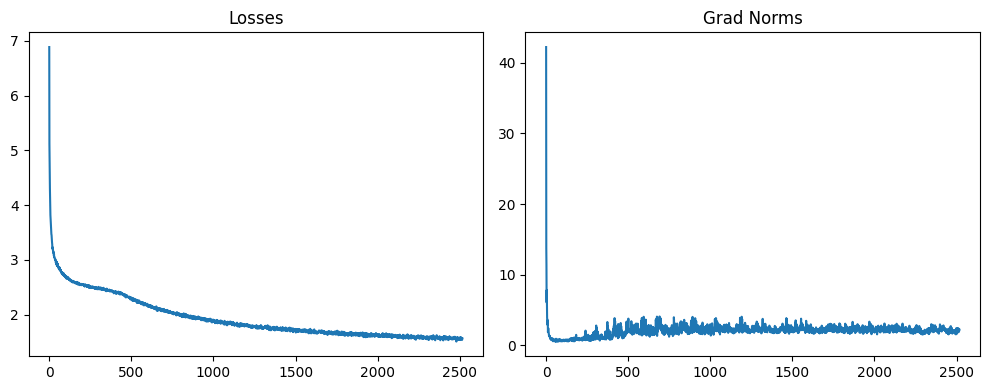

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Left plot
axes[0].plot(losses)
axes[0].set_title("Losses")

# Right plot
axes[1].plot(grad_norms)   # replace with your second dataset
axes[1].set_title("Grad Norms")

plt.tight_layout()
plt.show()

In [35]:
model.eval()
print(model.generate("We are accounted poor citizens, the patricians good.", max_len=200))

 Your from away!
Have pluters!

RANCHELLIO:
Gounds, a should me, are marrry: I here to tack:
I willican agains churp fareweed-Dexcinge in
Say, what more, so? nown beforme done for butt
herty coulds to


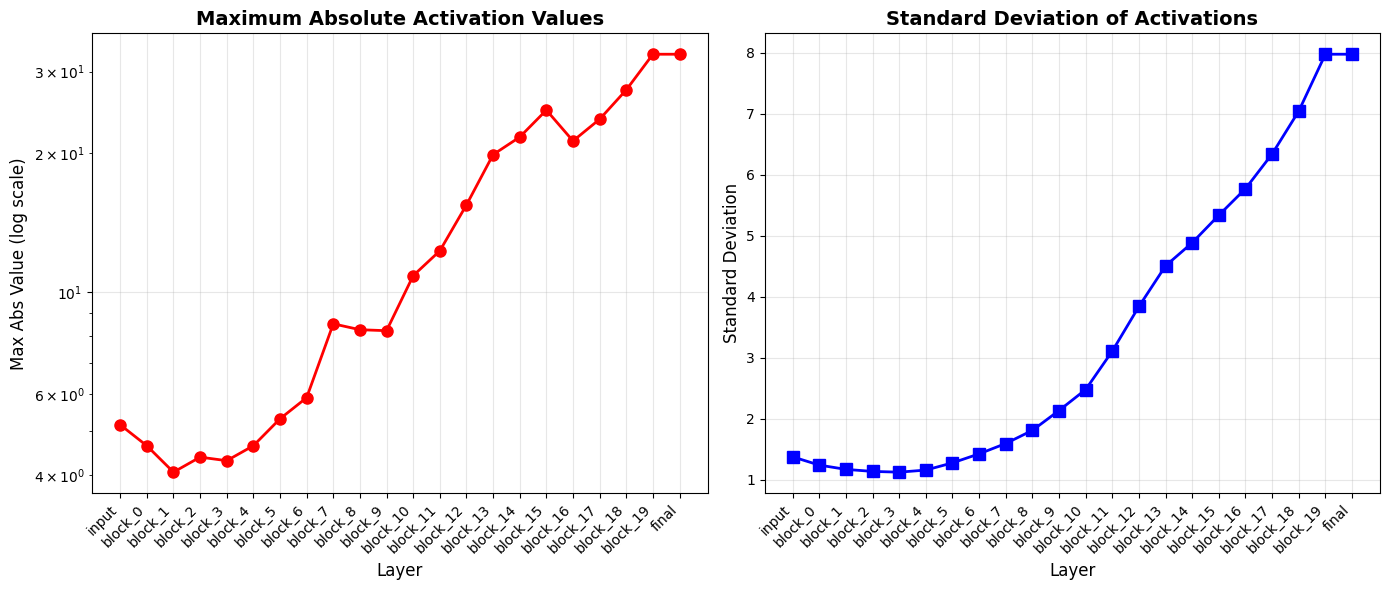


ACTIVATION STATISTICS
Layer                   Mean          Std      Max Abs
----------------------------------------------------------------------
input                 0.0213       1.3734       5.1489
block_0              -0.0090       1.2378       4.6371
block_1              -0.0235       1.1678       4.0646
block_2              -0.0650       1.1344       4.3813
block_3               0.0185       1.1221       4.3040
block_4               0.0340       1.1566       4.6377
block_5               0.0309       1.2744       5.3049
block_6               0.0604       1.4224       5.8938
block_7               0.0235       1.5921       8.5208
block_8              -0.0480       1.8072       8.2732
block_9               0.0037       2.1329       8.2330
block_10             -0.1197       2.4767      10.8337
block_11             -0.2488       3.1074      12.2635
block_12             -0.1799       3.8396      15.4207
block_13             -0.1237       4.5059      19.8175
block_14             -0.13

In [36]:
# Track activations - respect the layer_norm_enabled flag
def track_block_activations(model, x):
    """Track activations at the output of each block."""
    stats = []
    
    model.eval()
    with torch.no_grad():
        # Get embeddings
        x = model.token_embedding_table(x)
        pos = torch.arange(x.size(1), device=x.device)
        pos_emb = model.position_embedding_table(pos).unsqueeze(0)
        x = x + pos_emb
        
        # Track initial state
        stats.append({
            'layer': 'input',
            'mean': x.mean().item(),
            'std': x.std().item(),
            'max_abs': x.abs().max().item()
        })
        
        # Track through each block
        for i, block in enumerate(model.blocks):
            x = block(x)
            stats.append({
                'layer': f'block_{i}',
                'mean': x.mean().item(),
                'std': x.std().item(),
                'max_abs': x.abs().max().item()
            })
        
        # Only apply final layer norm if enabled (same as model's forward pass)
        if CONFIG["layer_norm_enabled"]:
            x = model.ln_final(x)
            stats.append({
                'layer': 'final_ln',
                'mean': x.mean().item(),
                'std': x.std().item(),
                'max_abs': x.abs().max().item()
            })
        else:
            # Track the raw output from last block (no normalization)
            stats.append({
                'layer': 'final',
                'mean': x.mean().item(),
                'std': x.std().item(),
                'max_abs': x.abs().max().item()
            })
    
    return stats

# Get a sample batch
x, y = sample_batch(1)
x = x.to(DEVICE)

# Track activations
stats = track_block_activations(model, x)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

layers = [s['layer'] for s in stats]
max_abs = [s['max_abs'] for s in stats]
stds = [s['std'] for s in stats]

# Plot 1: Maximum absolute values (log scale)
axes[0].semilogy(max_abs, marker='o', linewidth=2, markersize=8, color='red')
axes[0].set_title('Maximum Absolute Activation Values', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Layer', fontsize=12)
axes[0].set_ylabel('Max Abs Value (log scale)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(len(layers)))
axes[0].set_xticklabels(layers, rotation=45, ha='right')

# Plot 2: Standard deviation
axes[1].plot(stds, marker='s', linewidth=2, markersize=8, color='blue')
axes[1].set_title('Standard Deviation of Activations', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Layer', fontsize=12)
axes[1].set_ylabel('Standard Deviation', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(len(layers)))
axes[1].set_xticklabels(layers, rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*70)
print("ACTIVATION STATISTICS")
print("="*70)
print(f"{'Layer':<15} {'Mean':>12} {'Std':>12} {'Max Abs':>12}")
print("-"*70)
for s in stats:
    print(f"{s['layer']:<15} {s['mean']:>12.4f} {s['std']:>12.4f} {s['max_abs']:>12.4f}")
print("="*70)

# Calculate growth rate
if len(max_abs) > 1:
    growth_rate = max_abs[-1] / max_abs[0] if max_abs[0] != 0 else float('inf')
    print(f"\nActivation Growth Rate (Final/Initial): {growth_rate:.2f}x")
    print(f"Initial max abs: {max_abs[0]:.4f}")
    print(f"Final max abs: {max_abs[-1]:.4f}")